# V3 피처 분석 — 장르 제외 버전

**히스토리 비교 목적:** 장르 특성이 모델 성능에 미치는 영향을 파악합니다.

**분석 순서**
1. 데이터 로드 & 전처리
2. 장르 변수 제거 → Dataset NG 생성
3. 기준 모델 학습 → SHAP 중요도 확보
4. VIF + SHAP 결합 반복 제거 → Dataset NG-VIF 생성
5. 3개 데이터셋 성능 비교 (원본 / 장르제외 / 장르제외+VIF정제)
6. XAI 분석 (SHAP / Permutation / Surrogate Tree / Counterfactual)

| 데이터셋 | 설명 |
|---------|------|
| Dataset 1   | V3 원본 |
| Dataset NG  | 장르 변수 제거 후 |
| Dataset NG-VIF | 장르 제거 + VIF+SHAP 반복 정제 후 |

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import xgboost as xgb
import shap

BASE = Path('../..').resolve()
SEED = 42

df = pd.read_csv(
    BASE / '_data/02_interim/260513 feature/Membership_v4.csv',
    encoding='utf-8-sig'
)
print(f'V4 shape: {df.shape}')
df.head(3)

V4 shape: (23343, 91)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,payment_device,is_user_verified,gender,...,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4.0,1,0,pc,1,F,...,0.003861,0.389961,0.361004,0.0,0.000000,0.013514,0.0,0.0,0.0,0.001931
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1.0,1,1,pc,1,F,...,0.000000,0.250000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,2.0,1,0,android,1,F,...,0.000000,0.000000,0.992248,0.0,0.007752,0.000000,0.0,0.0,0.0,0.000000


In [12]:
EXCLUDE = [
    'USER_KEY', 'product_code', 'payment_device',
    'gender', 'reg_date', 'end_date', 'is_repurchase',
    'billing_method','price','max_screen','age',
    'reg_hour',
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    if col not in EXCLUDE:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT1 = [c for c in df_enc.columns if c not in EXCLUDE]
X1    = df_enc[FEAT1].fillna(0)
y     = df_enc['is_repurchase']

# 장르 관련 변수 정의
GENRE_COLS = [
    'action_adventure_ratio', 'family_animation_ratio', 'drama_ratio',
    'thriller_crime_ratio', 'sf_fantasy_ratio', 'comedy_ratio',
    'romance_ratio', 'horror_ratio', 'documentary_ratio',
    'historical_war_ratio', 'other_ratio', 'genre_diversity_count'
]
GENRE_COLS = [c for c in GENRE_COLS if c in FEAT1]

# Dataset NG: 장르 제외
FEAT_NG = [c for c in FEAT1 if c not in GENRE_COLS]
X_NG    = X1[FEAT_NG]

print(f'Dataset 1  (원본):    {len(FEAT1)}개')
print(f'제거 장르 변수:        {len(GENRE_COLS)}개 -> {GENRE_COLS}')
print(f'Dataset NG (장르제외): {len(FEAT_NG)}개')
print(f'이탈(0): {(y==0).sum():,}명 / 재구매(1): {(y==1).sum():,}명')

Dataset 1  (원본):    79개
제거 장르 변수:        12개 -> ['action_adventure_ratio', 'family_animation_ratio', 'drama_ratio', 'thriller_crime_ratio', 'sf_fantasy_ratio', 'comedy_ratio', 'romance_ratio', 'horror_ratio', 'documentary_ratio', 'historical_war_ratio', 'other_ratio', 'genre_diversity_count']
Dataset NG (장르제외): 67개
이탈(0): 6,641명 / 재구매(1): 16,702명


## 1. 기준 모델 학습 & SHAP 중요도 확인

장르 제외 변수셋(Dataset NG)으로 먼저 모델을 학습해 SHAP 중요도를 확보합니다.
이후 VIF+SHAP 반복 제거에 활용합니다.

In [13]:
X_tr_ng, X_te_ng, y_tr_ng, y_te_ng = train_test_split(
    X_NG, y, test_size=0.2, stratify=y, random_state=SEED
)
spw = (y_tr_ng==0).sum() / (y_tr_ng==1).sum()

model_ng = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_ng.fit(X_tr_ng, y_tr_ng, eval_set=[(X_te_ng, y_te_ng)], verbose=False)

y_pred_ng  = model_ng.predict(X_te_ng)
y_proba_ng = model_ng.predict_proba(X_te_ng)[:,1]
print(f'[장르제외 기준 모델] AUC={roc_auc_score(y_te_ng, y_proba_ng):.4f}  '
      f'F1={f1_score(y_te_ng, y_pred_ng):.4f}  변수={len(FEAT_NG)}개')

# SHAP 중요도
explainer_ng = shap.TreeExplainer(model_ng)
shap_ng      = explainer_ng.shap_values(X_te_ng)

shap_importance = pd.DataFrame({
    '변수': FEAT_NG,
    'SHAP': np.abs(shap_ng).mean(axis=0)
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_importance.index += 1

print('\n=== SHAP 중요도 (상위 20) ===')
print(shap_importance.head(20).to_string())

[장르제외 기준 모델] AUC=0.8412  F1=0.8274  변수=67개

=== SHAP 중요도 (상위 20) ===
                         변수      SHAP
1        watch_time(min)_w3  0.461465
2        retention_w2_ratio  0.332368
3              is_promotion  0.311669
4          is_cold_start_3d  0.302008
5        retention_w3_ratio  0.255159
6        diff_between_w2_w1  0.191389
7        diff_between_w3_w2  0.163112
8      avg_ott_release_year  0.152666
9    median_watch_time(min)  0.146422
10       is_churn_prevented  0.122870
11             unique_movie  0.113778
12         watch_session_w3  0.108969
13       diff_between_w3_w1  0.108402
14            max_day_share  0.104914
15  new_movie_in_365d_ratio  0.098901
16      max_watch_time(min)  0.097489
17              is_standard  0.092053
18      old_movie_ratio(5y)  0.084154
19               is_premium  0.083971
20      std_watch_time(min)  0.083750


## 2. VIF + SHAP 결합 반복 제거 → Dataset NG-VIF 생성

장르 제외 변수셋에서 추가로 VIF+SHAP 반복 제거를 적용합니다.

**알고리즘:**
1. VIF 계산
2. VIF > 10인 변수 중 SHAP 중요도 가장 낮은 것 1개 제거
3. VIF 재계산 → 임계값 이하 도달 시 종료

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 10

def calc_vif(X_df):
    Xv = X_df.select_dtypes(include=[np.number]).copy()
    Xv = Xv.drop(columns=[c for c in Xv.columns if Xv[c].var() == 0])
    Xv.insert(0, 'const', 1)
    vals = Xv.values.astype(float)
    result = []
    for i in range(1, len(Xv.columns)):
        try:
            v = variance_inflation_factor(vals, i)
        except Exception:
            v = np.inf
        result.append({'변수': Xv.columns[i], 'VIF': v})
    return pd.DataFrame(result)

shap_dict = dict(zip(shap_importance['변수'], shap_importance['SHAP']))

FEAT_NGVIF  = FEAT_NG.copy()
removed_log = []
print(f'시작: {len(FEAT_NGVIF)}개 변수 | VIF 임계값: {VIF_THRESHOLD}\n')

while True:
    vif_df   = calc_vif(X_NG[FEAT_NGVIF])
    high_vif = vif_df[np.isinf(vif_df['VIF']) | (vif_df['VIF'] > VIF_THRESHOLD)].copy()

    if len(high_vif) == 0:
        print(f'\n완료! 모든 변수 VIF <= {VIF_THRESHOLD}  (최종 변수: {len(FEAT_NGVIF)}개)')
        break

    high_vif['SHAP'] = high_vif['변수'].map(shap_dict).fillna(0)
    target   = high_vif.sort_values('SHAP').iloc[0]
    vif_str  = 'inf' if np.isinf(target['VIF']) else f"{target['VIF']:.1f}"

    FEAT_NGVIF.remove(target['변수'])
    step = len(removed_log) + 1
    removed_log.append({
        'step': step, '제거변수': target['변수'],
        'VIF': vif_str, 'SHAP': round(target['SHAP'], 4),
        '잔여변수': len(FEAT_NGVIF)
    })
    print(f"[{step:2d}] 제거: {target['변수']:<38}  "
          f"VIF={vif_str:>8}  SHAP={target['SHAP']:.4f}  남은: {len(FEAT_NGVIF)}개")

X_NGVIF = X_NG[FEAT_NGVIF]
print(f'\nDataset NG: {len(FEAT_NG)}개 -> Dataset NG-VIF: {len(FEAT_NGVIF)}개  '
      f'({len(FEAT_NG)-len(FEAT_NGVIF)}개 추가 제거)')
print('\n=== 제거 로그 ===')
print(pd.DataFrame(removed_log).to_string(index=False))

# ── 최종 VIF 검증 ──────────────────────────────────────────────────────────────
print('\n=== 최종 VIF 검증 (잔류 변수 전체) ===')
final_vif = calc_vif(X_NGVIF).sort_values('VIF', ascending=False).reset_index(drop=True)
final_vif['위험도'] = final_vif['VIF'].apply(lambda v: '주의(5~10)' if v > 5 else '양호')
print(final_vif.to_string())
print(f'\nVIF 최대값: {final_vif["VIF"].max():.2f}  /  평균: {final_vif["VIF"].mean():.2f}')

시작: 67개 변수 | VIF 임계값: 10

[ 1] 제거: reg_hour_afternoon                      VIF=     inf  SHAP=0.0080  남은: 66개
[ 2] 제거: active_ratio                            VIF=     inf  SHAP=0.0085  남은: 65개
[ 3] 제거: watch_session_w1                        VIF=     inf  SHAP=0.0149  남은: 64개
[ 4] 제거: payment_is_android                      VIF=    16.2  SHAP=0.0166  남은: 63개
[ 5] 제거: total_watch_count                       VIF=    42.8  SHAP=0.0201  남은: 62개
[ 6] 제거: new_movie_in_180d_ratio                 VIF=    12.5  SHAP=0.0310  남은: 61개
[ 7] 제거: max_inactive_gap_days                   VIF=    12.0  SHAP=0.0324  남은: 60개
[ 8] 제거: watch_days                              VIF=    12.5  SHAP=0.0338  남은: 59개
[ 9] 제거: watch_per_day                           VIF=    13.8  SHAP=0.0353  남은: 58개
[10] 제거: total_watch_time(min)                   VIF=     inf  SHAP=0.0511  남은: 57개
[11] 제거: max_daily_watch_time(min)               VIF=    11.0  SHAP=0.0574  남은: 56개
[12] 제거: watch_time(min)_w2                      V

## 3. 3개 데이터셋 성능 비교

[Dataset1:   V3 원본]  AUC=0.8825  F1=0.8539  변수=79개
[Dataset NG: 장르 제외]  AUC=0.8412  F1=0.8274  변수=67개
[Dataset NG-VIF: 장르제외+VIF정제]  AUC=0.8443  F1=0.8358  변수=51개

=== 최종 성능 비교 ===
                        모델  변수 수  AUC-ROC     F1  Precision  Recall
         Dataset1:   V3 원본    79   0.8825 0.8539     0.8988  0.8132
         Dataset NG: 장르 제외    67   0.8412 0.8274     0.8794  0.7812
Dataset NG-VIF: 장르제외+VIF정제    51   0.8443 0.8358     0.8815  0.7947


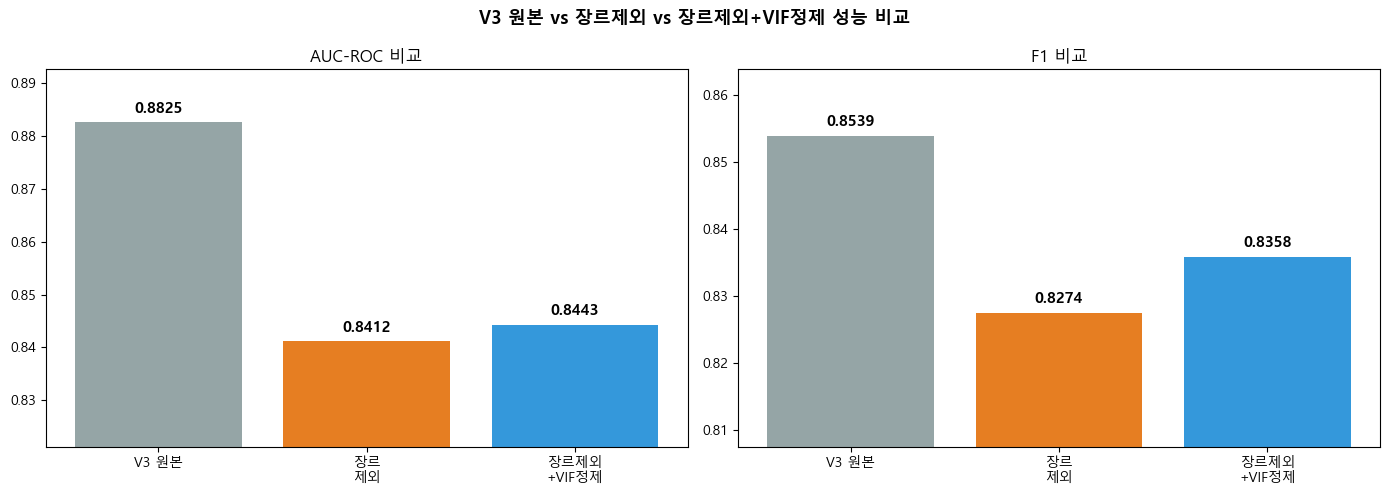


[최종 모델] AUC=0.8443  변수=51개  (XAI 분석에 사용)


In [15]:
def train_eval(X, y_all, label):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y_all, test_size=0.2, stratify=y_all, random_state=SEED
    )
    spw_i = (ytr==0).sum() / (ytr==1).sum()
    m = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw_i, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    yp  = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:,1]
    r = {
        '모델': label, '변수 수': X.shape[1],
        'AUC-ROC':   round(roc_auc_score(yte, ypr), 4),
        'F1':        round(f1_score(yte, yp), 4),
        'Precision': round(precision_score(yte, yp), 4),
        'Recall':    round(recall_score(yte, yp), 4),
    }
    print(f'[{label}]  AUC={r["AUC-ROC"]:.4f}  F1={r["F1"]:.4f}  변수={X.shape[1]}개')
    return r

results = [
    train_eval(X1,      y, 'Dataset1:   V3 원본'),
    train_eval(X_NG,    y, 'Dataset NG: 장르 제외'),
    train_eval(X_NGVIF, y, 'Dataset NG-VIF: 장르제외+VIF정제'),
]
result_df = pd.DataFrame(results)

print('\n=== 최종 성능 비교 ===')
print(result_df.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_labels = ['V3 원본', '장르\n제외', '장르제외\n+VIF정제']
colors     = ['#95a5a6', '#e67e22', '#3498db']
for ax, metric in zip(axes, ['AUC-ROC', 'F1']):
    vals = result_df[metric].tolist()
    bars = ax.bar(range(3), vals, color=colors)
    ax.set_title(f'{metric} 비교')
    ax.set_xticks(range(3))
    ax.set_xticklabels(bar_labels)
    ax.set_ylim(max(0, min(vals)-0.02), max(vals)+0.01)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.suptitle('V3 원본 vs 장르제외 vs 장르제외+VIF정제 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# XAI용 최종 모델
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_NGVIF, y, test_size=0.2, stratify=y, random_state=SEED
)
spw_f = (y_tr_f==0).sum() / (y_tr_f==1).sum()
model_final = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw_f, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_final.fit(X_tr_f, y_tr_f, eval_set=[(X_te_f, y_te_f)], verbose=False)
print(f'\n[최종 모델] AUC={roc_auc_score(y_te_f, model_final.predict_proba(X_te_f)[:,1]):.4f}  '
      f'변수={len(FEAT_NGVIF)}개  (XAI 분석에 사용)')

## 4. XAI 분석 (장르제외+VIF정제 모델 기준)
### 4-1. SHAP

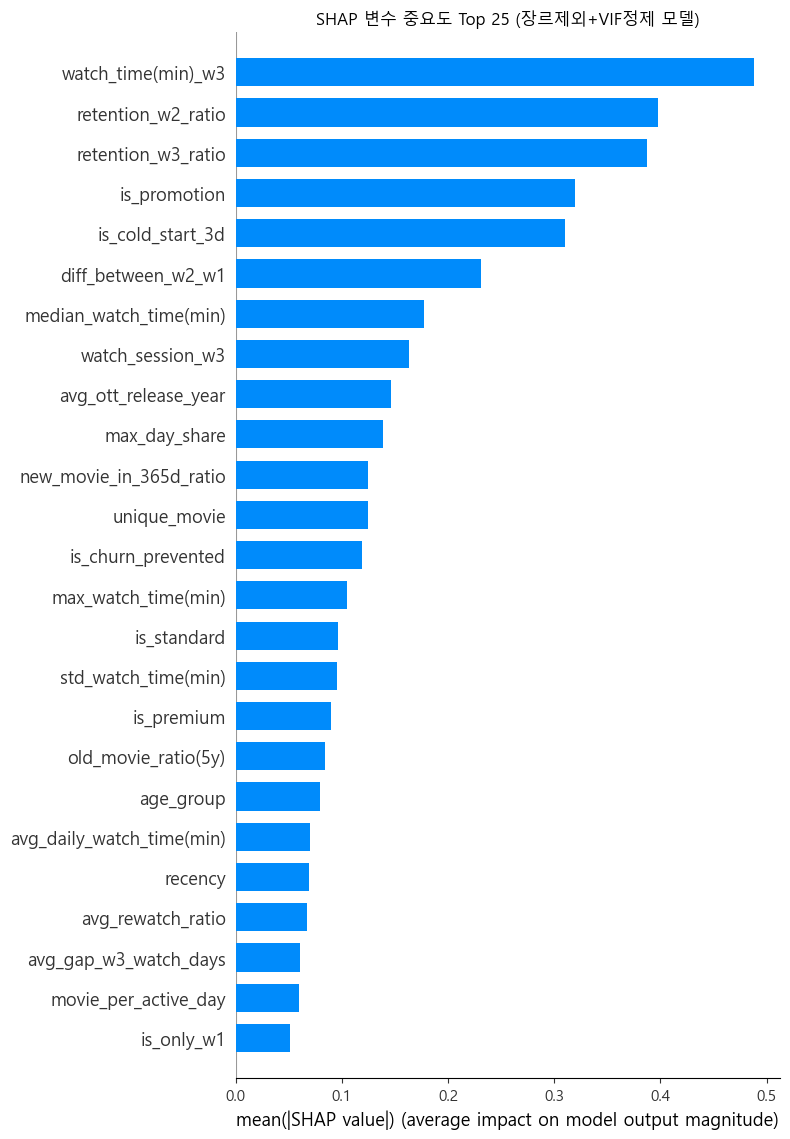

=== SHAP 중요도 (상위 25) ===
                           변수      SHAP
1          watch_time(min)_w3  0.488142
2          retention_w2_ratio  0.397866
3          retention_w3_ratio  0.387578
4                is_promotion  0.319132
5            is_cold_start_3d  0.310299
6          diff_between_w2_w1  0.231041
7      median_watch_time(min)  0.177331
8            watch_session_w3  0.163563
9        avg_ott_release_year  0.145881
10              max_day_share  0.138548
11    new_movie_in_365d_ratio  0.124999
12               unique_movie  0.124613
13         is_churn_prevented  0.118771
14        max_watch_time(min)  0.105105
15                is_standard  0.095962
16        std_watch_time(min)  0.095412
17                 is_premium  0.089910
18        old_movie_ratio(5y)  0.083786
19                  age_group  0.079353
20  avg_daily_watch_time(min)  0.069732
21                    recency  0.069217
22          avg_rewatch_ratio  0.066966
23      avg_gap_w3_watch_days  0.060468
24       movie_

In [16]:
explainer_final = shap.TreeExplainer(model_final)
shap_final      = explainer_final.shap_values(X_te_f)

shap_df = pd.DataFrame({
    '변수': FEAT_NGVIF,
    'SHAP': np.abs(shap_final).mean(axis=0)
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_df.index += 1

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_final, X_te_f, plot_type='bar', show=False, max_display=25)
plt.title('SHAP 변수 중요도 Top 25 (장르제외+VIF정제 모델)')
plt.tight_layout(); plt.show()

print('=== SHAP 중요도 (상위 25) ===')
print(shap_df.head(25).to_string())

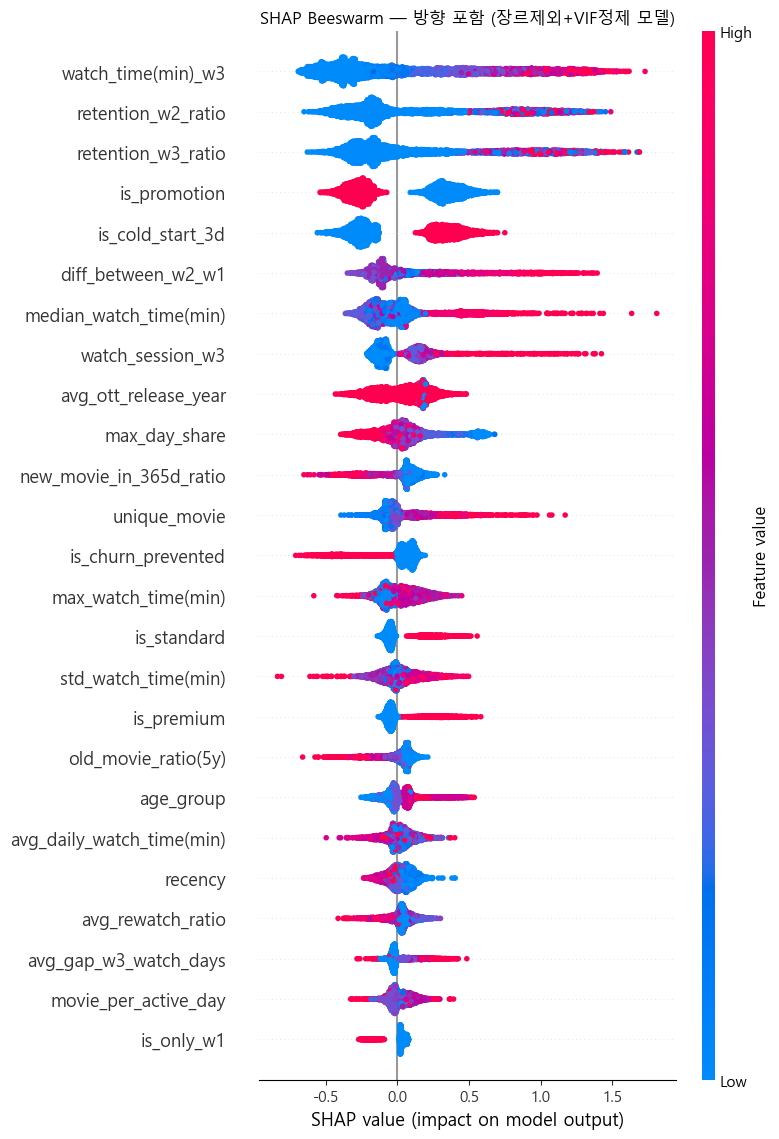

In [17]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_final, X_te_f, show=False, max_display=25)
plt.title('SHAP Beeswarm — 방향 포함 (장르제외+VIF정제 모델)')
plt.tight_layout(); plt.show()

### 4-2. Permutation Importance

=== Permutation Importance ===
                           변수  AUC감소(평균)      표준편차
1          retention_w2_ratio   0.047937  0.003582
2          retention_w3_ratio   0.041641  0.003970
3          watch_time(min)_w3   0.040959  0.002160
4          diff_between_w2_w1   0.014494  0.002296
5            is_cold_start_3d   0.014046  0.001579
6               max_day_share   0.012198  0.001209
7                is_promotion   0.010602  0.001672
8      median_watch_time(min)   0.009527  0.001012
9        avg_ott_release_year   0.007905  0.000661
10    new_movie_in_365d_ratio   0.006014  0.000922
11           watch_session_w3   0.004423  0.000871
12               unique_movie   0.002834  0.000829
13                 is_premium   0.002418  0.000572
14        old_movie_ratio(5y)   0.002342  0.000448
15                is_standard   0.002207  0.000643
16         is_churn_prevented   0.002075  0.001073
17        max_watch_time(min)   0.001978  0.000860
18                  age_group   0.001528  0.000730


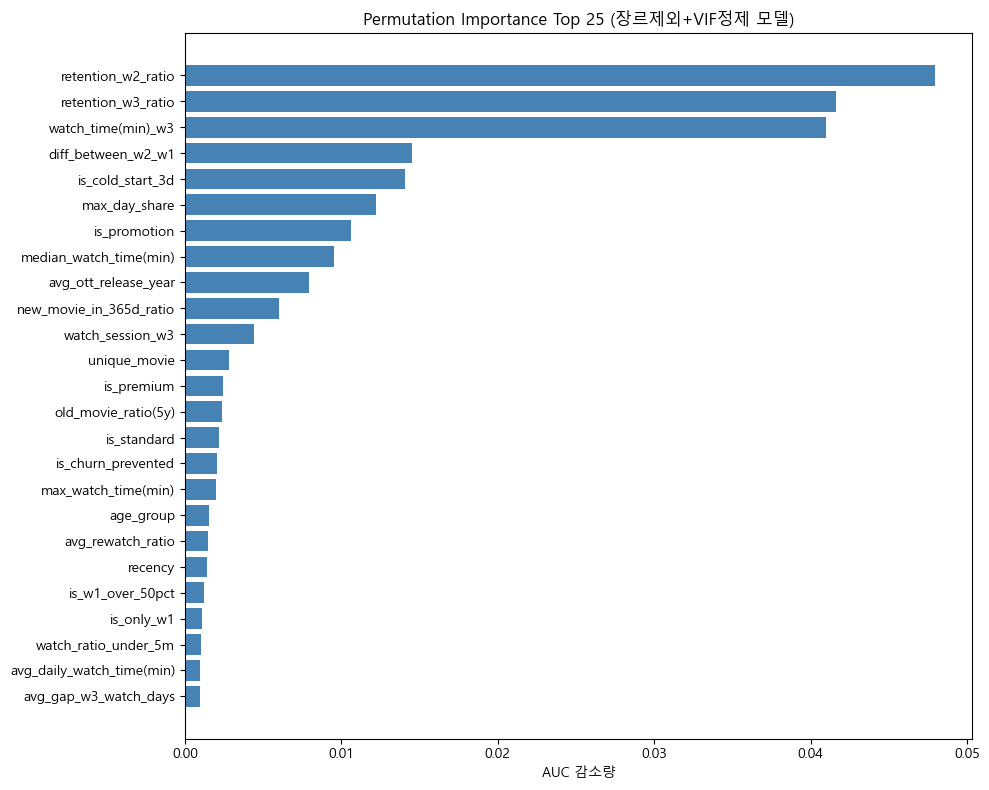

In [18]:
perm = permutation_importance(
    model_final, X_te_f, y_te_f,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_df = pd.DataFrame({
    '변수': FEAT_NGVIF,
    'AUC감소(평균)': perm.importances_mean,
    '표준편차':      perm.importances_std,
}).sort_values('AUC감소(평균)', ascending=False).reset_index(drop=True)
perm_df.index += 1

print('=== Permutation Importance ===')
print(perm_df.head(25).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
top = perm_df.head(25)
ax.barh(top['변수'][::-1], top['AUC감소(평균)'][::-1], color='steelblue')
ax.set_title('Permutation Importance Top 25 (장르제외+VIF정제 모델)')
ax.set_xlabel('AUC 감소량')
plt.tight_layout(); plt.show()

### 4-3. Surrogate Tree (규칙 추출)

=== Surrogate Tree 규칙 ===
|--- watch_time(min)_w3 <= 4.50
|   |--- diff_between_w2_w1 <= 5.50
|   |   |--- max_day_share <= 0.48
|   |   |   |--- is_promotion <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_promotion >  0.50
|   |   |   |   |--- class: 0
|   |   |--- max_day_share >  0.48
|   |   |   |--- watch_time(min)_w3 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- watch_time(min)_w3 >  1.50
|   |   |   |   |--- class: 0
|   |--- diff_between_w2_w1 >  5.50
|   |   |--- diff_between_w2_w1 <= 76.50
|   |   |   |--- avg_ott_release_year <= 2017.99
|   |   |   |   |--- class: 1
|   |   |   |--- avg_ott_release_year >  2017.99
|   |   |   |   |--- class: 0
|   |   |--- diff_between_w2_w1 >  76.50
|   |   |   |--- is_promotion <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_promotion >  0.50
|   |   |   |   |--- class: 1
|--- watch_time(min)_w3 >  4.50
|   |--- watch_time(min)_w3 <= 92.50
|   |   |--- retention_w2_ratio <= 0.06
|   |   |   |--- is_promotion <

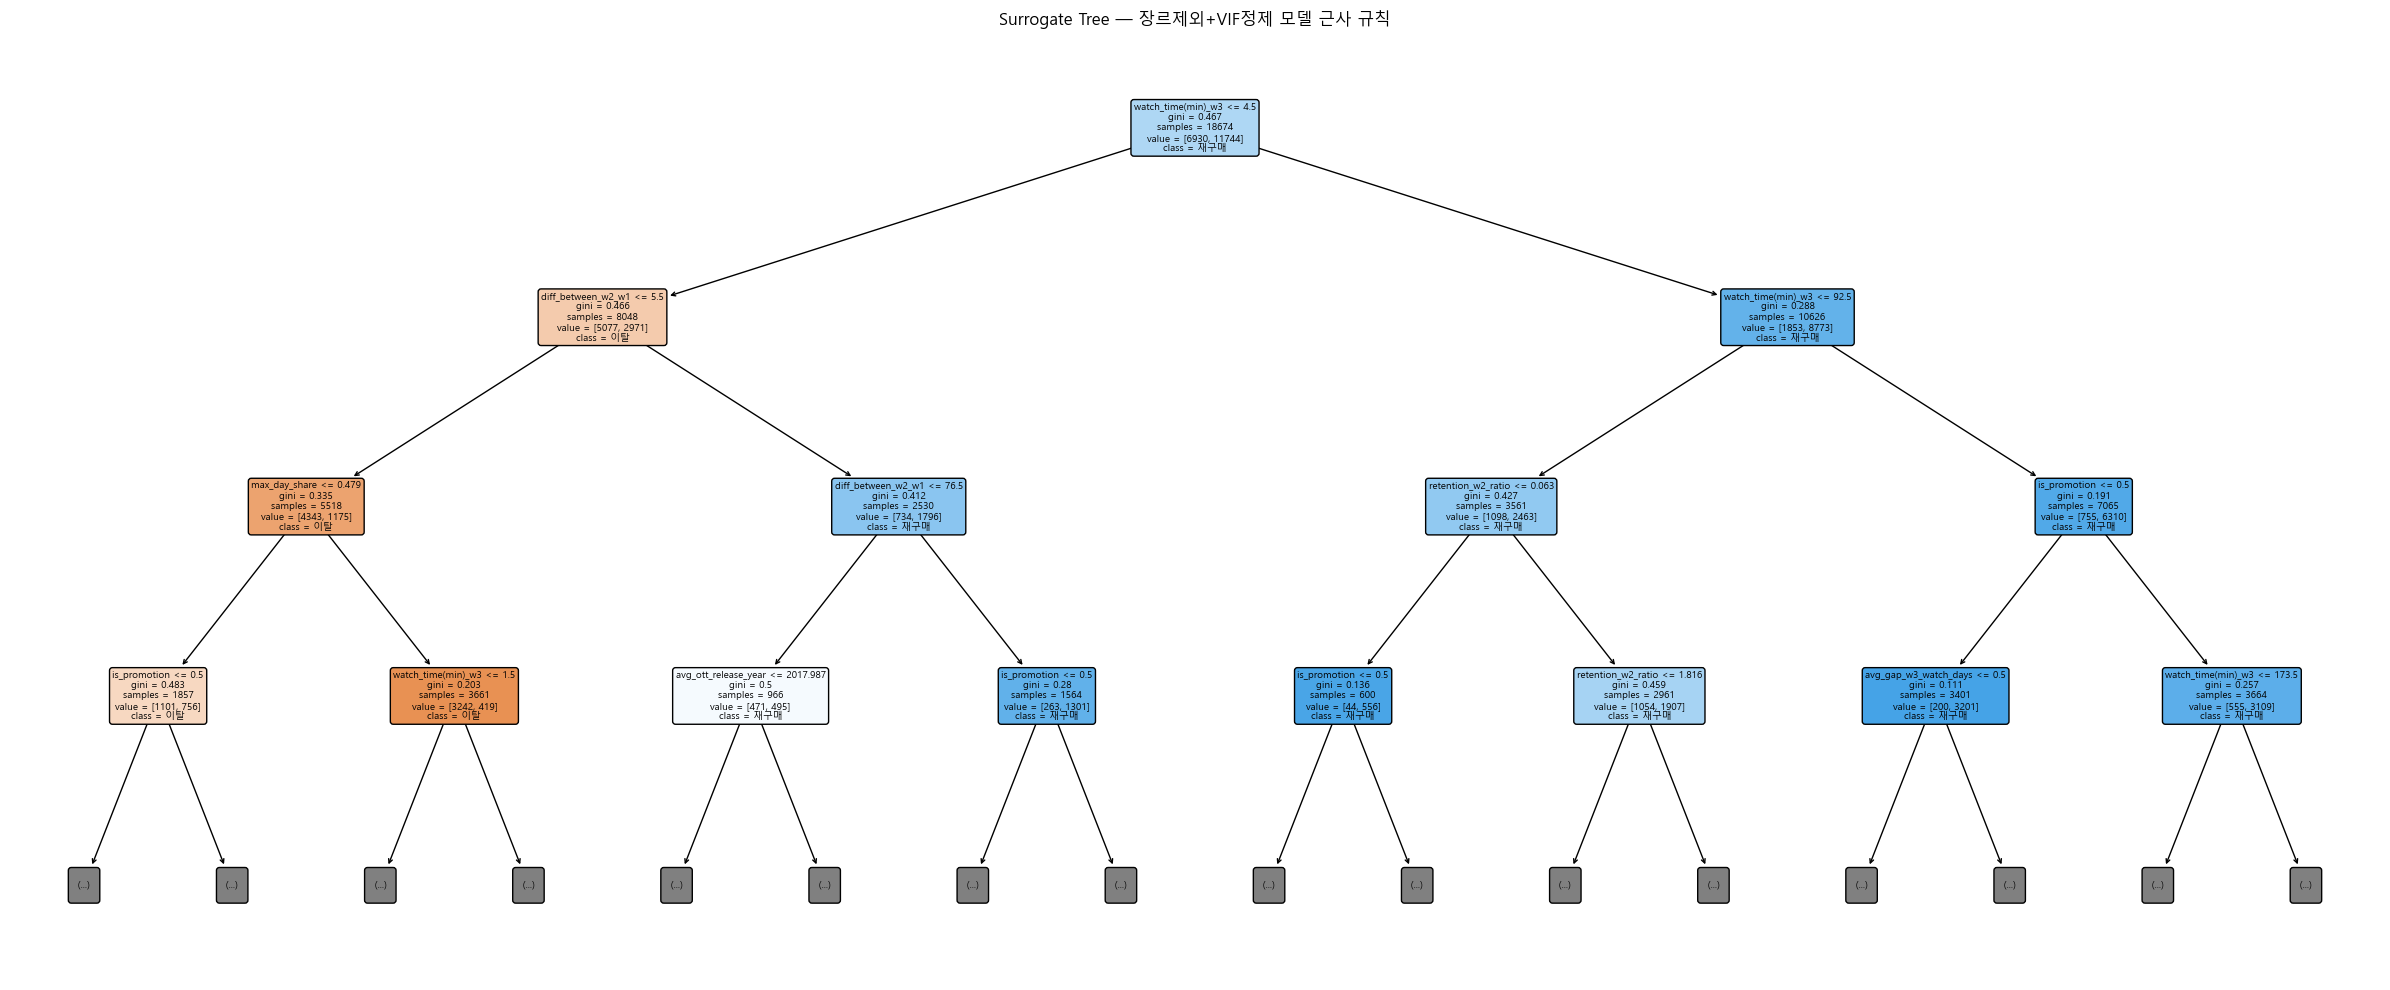

In [19]:
y_pred_tr_f = (model_final.predict_proba(X_tr_f)[:,1] > 0.5).astype(int)

surrogate = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surrogate.fit(X_tr_f, y_pred_tr_f)

print('=== Surrogate Tree 규칙 ===')
print(export_text(surrogate, feature_names=list(FEAT_NGVIF), max_depth=4))

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(surrogate, feature_names=list(FEAT_NGVIF),
          class_names=['이탈', '재구매'],
          filled=True, rounded=True, ax=ax, max_depth=3, fontsize=7)
plt.title('Surrogate Tree — 장르제외+VIF정제 모델 근사 규칙')
plt.tight_layout(); plt.show()

### 4-4. Counterfactual Explanation

선택 고객 재구매 확률: 2.2%

=== Counterfactual ===
                 변경 변수   원래 값  변경 값(Q75)  원래 확률  변경 후 확률  확률 변화
    watch_time(min)_w3    0.0     140.00  0.022    0.067  0.045
    diff_between_w2_w1   -4.0      68.00  0.022    0.036  0.014
    retention_w2_ratio    0.2       3.62  0.022    0.034  0.012
         max_day_share    1.0       0.89  0.022    0.034  0.011
      watch_session_w3    0.0       3.00  0.022    0.032  0.010
      is_cold_start_3d    0.0       1.00  0.022    0.031  0.009
    retention_w3_ratio    1.0       4.00  0.022    0.030  0.008
          is_promotion    1.0       1.00  0.022    0.022  0.000
  avg_ott_release_year 2015.0    2019.00  0.022    0.023  0.000
median_watch_time(min)    4.0      60.00  0.022    0.020 -0.002


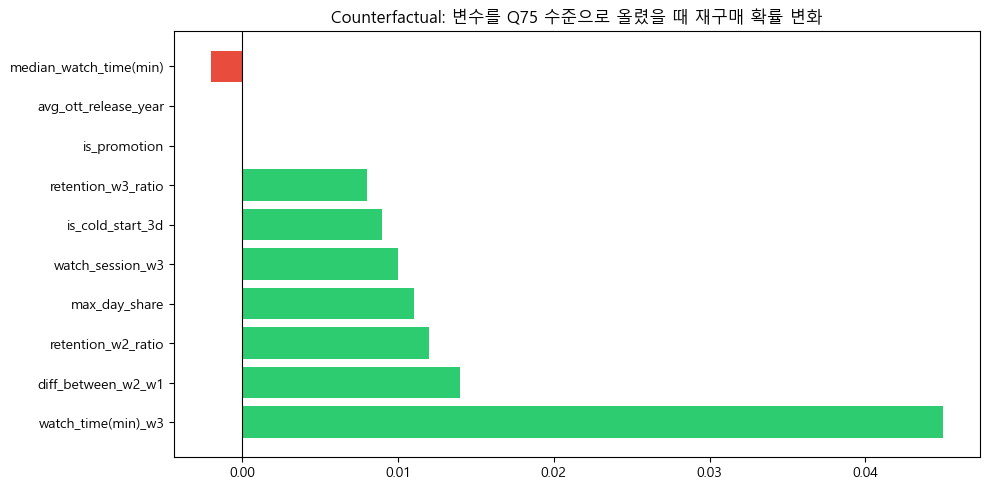

In [20]:
y_pred_te_f = model_final.predict_proba(X_te_f)[:,1]
churn_mask  = (y_pred_te_f < 0.4) & (y_te_f.values == 0)
churn_idx   = np.where(churn_mask)[0]
top_idx     = churn_idx[np.argsort(y_pred_te_f[churn_idx])[0]]
churn_user  = X_te_f.iloc[top_idx]
base_prob   = model_final.predict_proba(churn_user.values.reshape(1, -1))[0, 1]
print(f'선택 고객 재구매 확률: {base_prob:.1%}')

key_feats = shap_df['변수'].head(10).tolist()
rows = []
for feat in key_feats:
    curr_val = churn_user[feat]
    q75      = X_te_f[feat].quantile(0.75)
    cf_user  = churn_user.copy()
    cf_user[feat] = q75
    cf_prob  = model_final.predict_proba(cf_user.values.reshape(1, -1))[0, 1]
    rows.append({
        '변경 변수':    feat,
        '원래 값':      round(curr_val, 2),
        '변경 값(Q75)': round(q75, 2),
        '원래 확률':    round(base_prob, 3),
        '변경 후 확률': round(cf_prob, 3),
        '확률 변화':    round(cf_prob - base_prob, 3),
    })

cf_df = pd.DataFrame(rows).sort_values('확률 변화', ascending=False)
print('\n=== Counterfactual ===')
print(cf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in cf_df['확률 변화']]
ax.barh(cf_df['변경 변수'], cf_df['확률 변화'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Counterfactual: 변수를 Q75 수준으로 올렸을 때 재구매 확률 변화')
plt.tight_layout(); plt.show()